In [1]:
# Paso 0: Imports básicos
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


Paso 1 – Cargar el dataset desde KaggleHub

In [2]:
# Paso 1: Descargar dataset desde KaggleHub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("berkerisen/wind-turbine-scada-dataset")

print("Path to dataset files:", path)


c:\Users\jfernandezp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\jfernandezp\.cache\kagglehub\datasets\berkerisen\wind-turbine-scada-dataset\versions\3


In [3]:
# Buscar archivos CSV dentro de la carpeta descargada
csv_files = glob.glob(os.path.join(path, "*.csv"))
csv_files


['C:\\Users\\jfernandezp\\.cache\\kagglehub\\datasets\\berkerisen\\wind-turbine-scada-dataset\\versions\\3\\T1.csv']

In [4]:
# Cargar el primer CSV encontrado
file_path = csv_files[0]
print("Usando archivo:", file_path)

df = pd.read_csv(file_path)
df.head()


Usando archivo: C:\Users\jfernandezp\.cache\kagglehub\datasets\berkerisen\wind-turbine-scada-dataset\versions\3\T1.csv


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


Paso 2 – Inspección rápida del dataset

In [5]:
# Paso 2: Exploración rápida

print("Forma del dataset (filas, columnas):", df.shape)
print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
display(df.head())

print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())


Forma del dataset (filas, columnas): (50530, 5)

Columnas:
Index(['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)',
       'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)'],
      dtype='object')

Tipos de datos:
Date/Time                         object
LV ActivePower (kW)              float64
Wind Speed (m/s)                 float64
Theoretical_Power_Curve (KWh)    float64
Wind Direction (°)               float64
dtype: object

Primeras filas:


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286



Valores nulos por columna:
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

Estadísticas descriptivas:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


Paso 3 – Limpiar y preparar columna de fecha

In [6]:
# Paso 3: Procesar la columna de fecha

# Primero quitamos espacios por si acaso
df["Date/Time"] = df["Date/Time"].str.strip()

# Indicamos el formato correcto: "día mes año hora:minuto"
df["Date/Time"] = pd.to_datetime(df["Date/Time"], format="%d %m %Y %H:%M")

df = df.sort_values("Date/Time").reset_index(drop=True)

# Crear también una copia con índice temporal
df = df.set_index("Date/Time")

# cambiar negativos de LV ActivePower (kW) por ceros
df["LV ActivePower (kW)"] = df["LV ActivePower (kW)"].apply(lambda x: max(x, 0))

df.head()


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


Paso 4 – Visualización básica

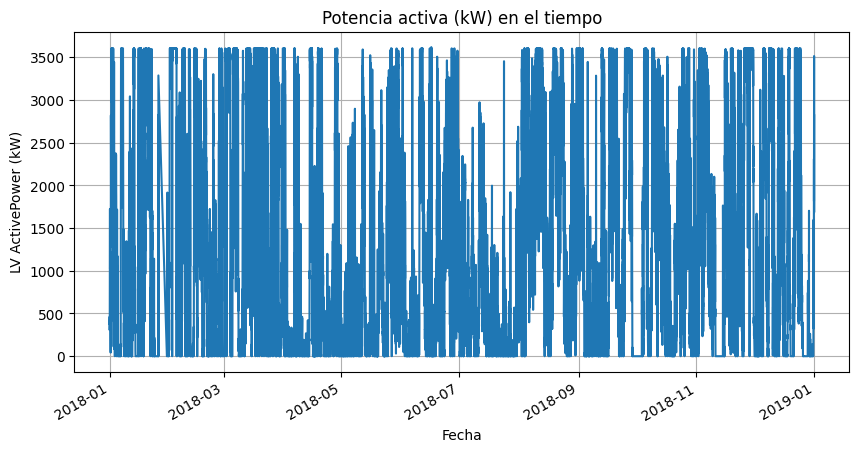

In [7]:
# Potencia activa a lo largo del tiempo
df["LV ActivePower (kW)"].plot(title="Potencia activa (kW) en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("LV ActivePower (kW)")
plt.show()

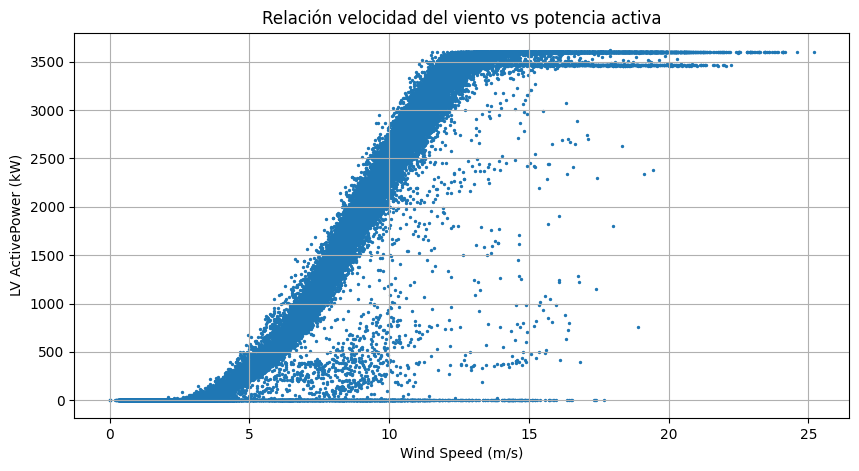

In [8]:
plt.scatter(df["Wind Speed (m/s)"], df["LV ActivePower (kW)"], s=2)
plt.title("Relación velocidad del viento vs potencia activa")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("LV ActivePower (kW)")
plt.show()

Paso 5 – Plantear el objetivo del modelo

    Nuestro objetivo: predecir LV ActivePower (kW) a partir de:

    Wind Speed (m/s)

    Theoretical_Power_Curve (KWh)

    Wind Direction (°)

    y más adelante quizá features temporales (hora del día, etc.) o lags (valores pasados).



In [9]:
# Paso 4: Ingeniería de características básicas

# Extraer información temporal
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

# Codificación cíclica: hora del día
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Codificación cíclica: día de la semana
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Codificación cíclica: mes
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df.head()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Date/Time,,,,,,,,,,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,0,0,1,0.0,1.0,0.0,1.0,0.5,0.866025
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,0,0,1,0.0,1.0,0.0,1.0,0.5,0.866025
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,0,0,1,0.0,1.0,0.0,1.0,0.5,0.866025
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,0,0,1,0.0,1.0,0.0,1.0,0.5,0.866025
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,0,0,1,0.0,1.0,0.0,1.0,0.5,0.866025


In [10]:


# Paso 5: Definir X (inputs) e y (target)

features = [
    "Wind Speed (m/s)",
    "Wind Direction (°)",
    "Theoretical_Power_Curve (KWh)",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos"
]

X = df[features]
y = df["LV ActivePower (kW)"]

X.head(), y.head()

(                     Wind Speed (m/s)  Wind Direction (°)  \
 Date/Time                                                   
 2018-01-01 00:00:00          5.311336          259.994904   
 2018-01-01 00:10:00          5.672167          268.641113   
 2018-01-01 00:20:00          5.216037          272.564789   
 2018-01-01 00:30:00          5.659674          271.258087   
 2018-01-01 00:40:00          5.577941          265.674286   
 
                      Theoretical_Power_Curve (KWh)  hour_sin  hour_cos  \
 Date/Time                                                                
 2018-01-01 00:00:00                     416.328908       0.0       1.0   
 2018-01-01 00:10:00                     519.917511       0.0       1.0   
 2018-01-01 00:20:00                     390.900016       0.0       1.0   
 2018-01-01 00:30:00                     516.127569       0.0       1.0   
 2018-01-01 00:40:00                     491.702972       0.0       1.0   
 
                      dow_sin  dow_co

 Paso 6 – Train/Test Split temporal (NO aleatorio)

In [11]:
# Paso 6: Train/Test Split temporal

split_ratio = 0.8  # 80% train, 20% test
split_index = int(len(df) * split_ratio)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40424, 10106, 40424, 10106)

Paso 7 – Entrenar un modelo base (RandomForestRegressor)

In [12]:
# Paso 7: Entrenamiento del modelo RandomForest

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,   # número de árboles
    max_depth=None,     # sin límite de profundidad
    random_state=42,    # reproducibilidad
    n_jobs=-1           # usa todos los cores disponibles
)

model.fit(X_train, y_train)

print("Modelo RandomForest entrenado.")

Modelo RandomForest entrenado.


Paso 8 – Predicción y evaluación

In [13]:
# Paso 8: Predicción y evaluación

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} kW")
print(f"RMSE : {rmse:.2f} kW")
print(f"R²   : {r2:.3f}")


MAE  : 405.38 kW
RMSE : 835.84 kW
R²   : 0.612


Paso 9 – Gráfico: Real vs Predicho en el tiempo

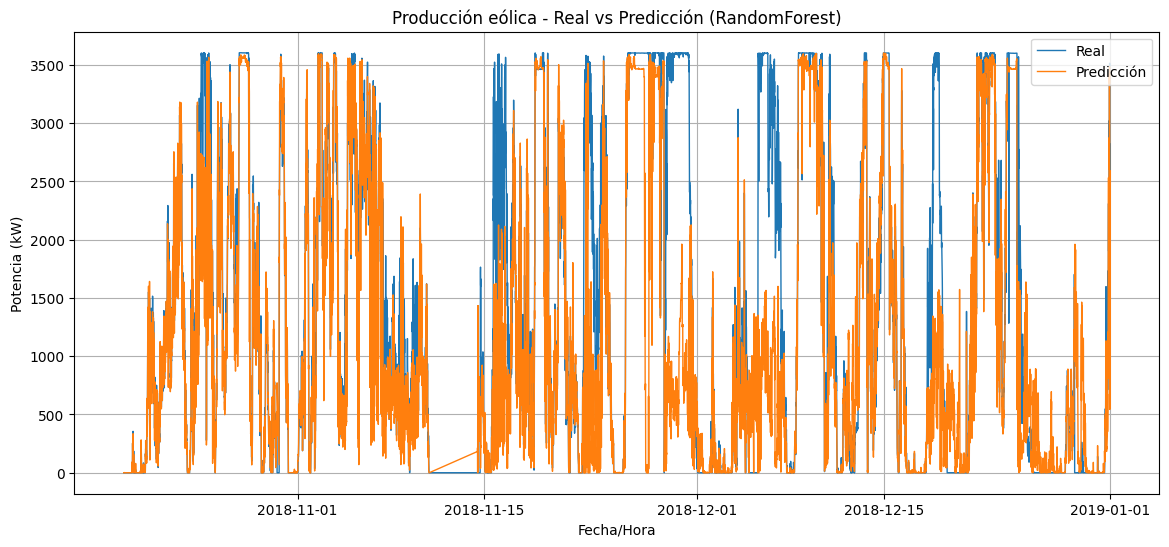

In [14]:
# Paso 9: Gráfico Real vs Predicción en el tiempo

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Real", linewidth=1)
plt.plot(y_test.index, y_pred, label="Predicción", linewidth=1)
plt.title("Producción eólica - Real vs Predicción (RandomForest)")
plt.ylabel("Potencia (kW)")
plt.xlabel("Fecha/Hora")
plt.legend()
plt.show()

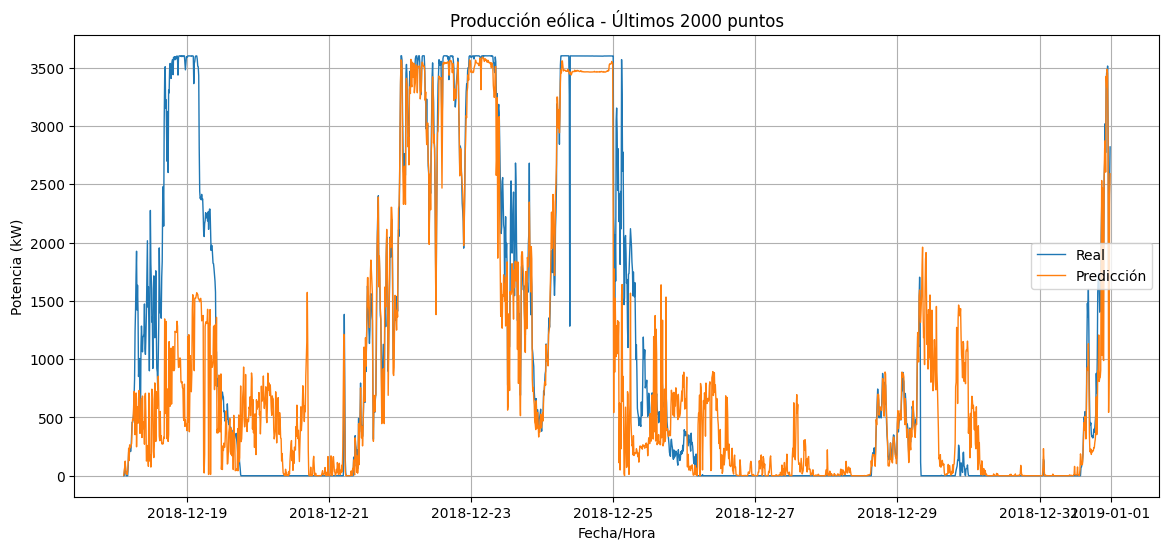

In [15]:
# Opcional: solo últimos N puntos para ver mejor
N = 2000  # por ejemplo
plt.figure(figsize=(14, 6))
plt.plot(y_test.index[-N:], y_test.values[-N:], label="Real", linewidth=1)
plt.plot(y_test.index[-N:], y_pred[-N:], label="Predicción", linewidth=1)
plt.title(f"Producción eólica - Últimos {N} puntos")
plt.ylabel("Potencia (kW)")
plt.xlabel("Fecha/Hora")
plt.legend()
plt.show()


Paso 10 – Importancia de características

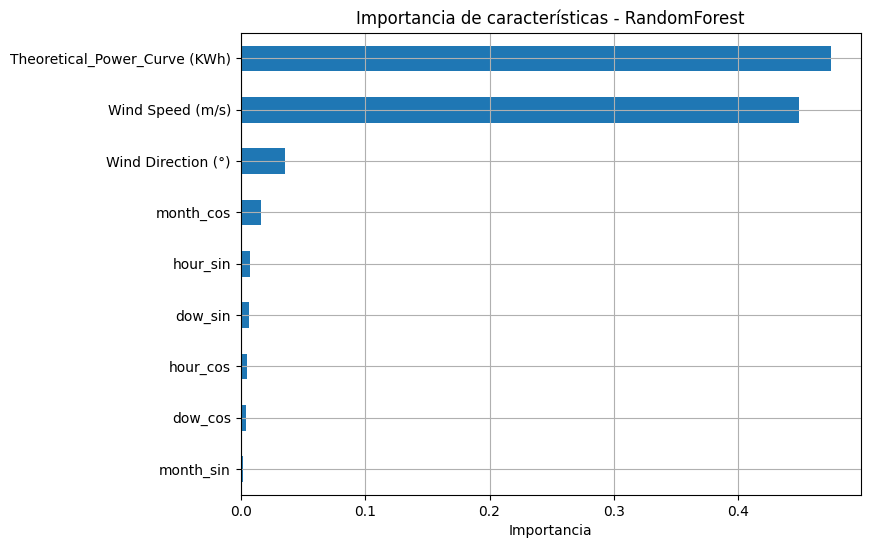

month_sin                        0.002107
dow_cos                          0.004191
hour_cos                         0.005207
dow_sin                          0.006413
hour_sin                         0.007305
month_cos                        0.016017
Wind Direction (°)               0.035683
Wind Speed (m/s)                 0.448437
Theoretical_Power_Curve (KWh)    0.474640
dtype: float64

In [16]:
# Paso 10: Importancia de características

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Importancia de características - RandomForest")
plt.xlabel("Importancia")
plt.show()

importances


Modelo simplificado (solo features importantes)

In [17]:
# Modelo simplificado: solo las dos features principales
X2 = df[[
    "Wind Speed (m/s)",
    "Theoretical_Power_Curve (KWh)"
]]

# Split temporal
split_idx = int(len(df)*0.8)
X2_train, X2_test = X2.iloc[:split_idx], X2.iloc[split_idx:]
y2_train, y2_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Entrenar modelo simplificado
model2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model2.fit(X2_train, y2_train)

# Evaluar
y2_pred = model2.predict(X2_test)

mae2  = mean_absolute_error(y2_test, y2_pred)
rmse2 = mean_squared_error(y2_test, y2_pred)**0.5
r22   = r2_score(y2_test, y2_pred)

#mae2, rmse2, r22

print(f"MAE  : {mae2:.2f} kW")
print(f"RMSE : {rmse2:.2f} kW")
print(f"R²   : {r22:.3f}")



MAE  : 237.43 kW
RMSE : 503.87 kW
R²   : 0.859


Modelo con Crear features temporales avanzadas

In [18]:
# Crear features avanzadas basadas en series temporales

df["wind_lag1"] = df["Wind Speed (m/s)"].shift(1)
df["wind_lag2"] = df["Wind Speed (m/s)"].shift(2)

df["power_lag1"] = df["LV ActivePower (kW)"].shift(1)

df["wind_roll3"]  = df["Wind Speed (m/s)"].rolling(3).mean()
df["wind_roll6"]  = df["Wind Speed (m/s)"].rolling(6).mean()

df["wind_std3"]   = df["Wind Speed (m/s)"].rolling(3).std()

# Eliminar filas con NaN causados por shift/rolling
df2 = df.dropna().copy()

df2.head()


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,wind_lag1,wind_lag2,power_lag1,wind_roll3,wind_roll6,wind_std3
Date/Time,,,,,,,,,,,,,,,,,,,
2018-01-01 00:50:00,402.391998,5.604052,499.436385,264.578613,0,0,1,0.000000,1.000000,0.0,1.0,0.5,0.866025,5.577941,5.659674,380.650696,5.613889,5.506868,0.041745
2018-01-01 01:00:00,447.605713,5.793008,557.372363,266.163605,1,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,5.604052,5.577941,402.391998,5.658334,5.587146,0.117360
2018-01-01 01:10:00,387.242188,5.306050,414.898179,257.949493,1,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,5.793008,5.604052,447.605713,5.567703,5.526127,0.245506
2018-01-01 01:20:00,463.651215,5.584629,493.677652,253.480698,1,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,5.306050,5.793008,387.242188,5.561229,5.587559,0.244321
2018-01-01 01:30:00,439.725708,5.523228,475.706783,258.723785,1,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,5.584629,5.306050,463.651215,5.471302,5.564818,0.146369


In [19]:
# Features importantes + features temporales avanzadas
features_advanced = [
    "Wind Speed (m/s)",
    "Theoretical_Power_Curve (KWh)",
    "wind_lag1",
    "wind_lag2",
    "power_lag1",
    "wind_roll3",
    "wind_roll6",
    "wind_std3"
]

X_adv = df2[features_advanced]
y_adv = df2["LV ActivePower (kW)"]

Hacemos un nuevo split temporal solo porque creamos un nuevo DataFrame (df2) después de aplicar lags y rollings, lo que:

cambia el número de filas

cambia los índices

elimina las primeras N filas por los shift() y rolling()

Por eso NO podemos reutilizar el split antiguo: la posición donde estaba el 80% ya no coincide.

In [20]:
#Nuevo split temporal

split_idx = int(len(df2) * 0.8)

X_adv_train = X_adv.iloc[:split_idx]
X_adv_test  = X_adv.iloc[split_idx:]

y_adv_train = y_adv.iloc[:split_idx]
y_adv_test  = y_adv.iloc[split_idx:]

In [21]:
#Entrenamiento del modelo avanzado

from sklearn.ensemble import RandomForestRegressor

model_adv = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_adv.fit(X_adv_train, y_adv_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
#Evaluación

y_adv_pred = model_adv.predict(X_adv_test)

mae_adv  = mean_absolute_error(y_adv_test, y_adv_pred)
rmse_adv = mean_squared_error(y_adv_test, y_adv_pred)**0.5
r2_adv   = r2_score(y_adv_test, y_adv_pred)

print(f"MAE  : {mae_adv:.2f} kW")
print(f"RMSE : {rmse_adv:.2f} kW")
print(f"R²   : {r2_adv:.3f}")

MAE  : 55.09 kW
RMSE : 121.04 kW
R²   : 0.992


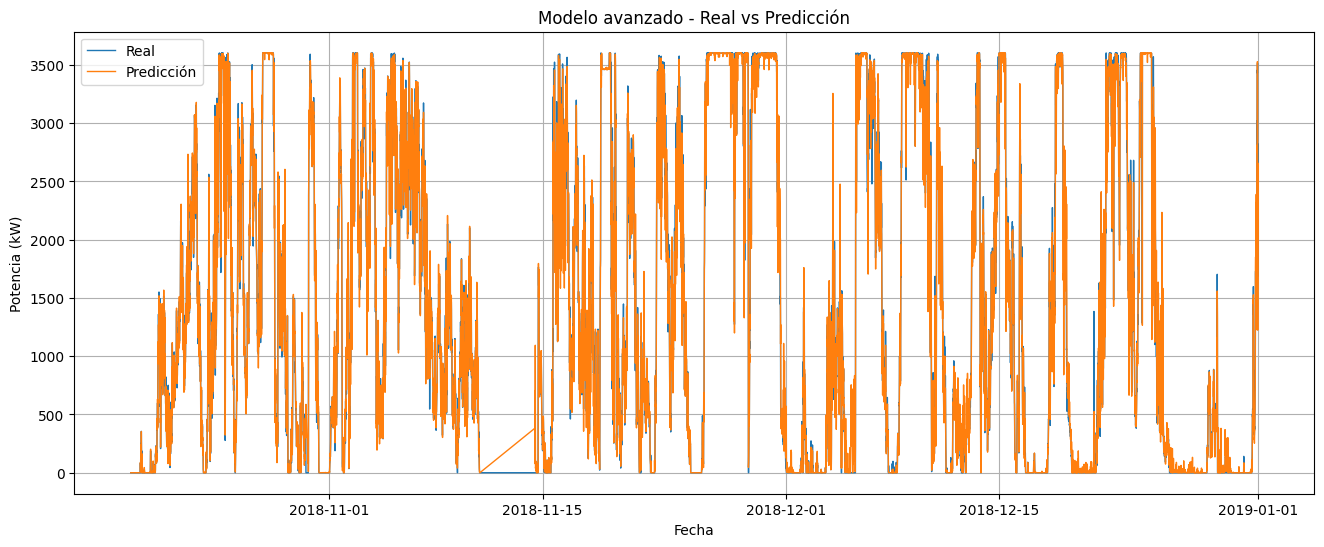

In [23]:
plt.figure(figsize=(16, 6))
plt.plot(y_adv_test.index, y_adv_test.values, label="Real", linewidth=1)
plt.plot(y_adv_test.index, y_adv_pred, label="Predicción", linewidth=1)
plt.title("Modelo avanzado - Real vs Predicción")
plt.ylabel("Potencia (kW)")
plt.xlabel("Fecha")
plt.legend()
plt.show()


Ajustar hiperparámetros del RandomForest

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Espacio de hiperparámetros
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,           # 30 pruebas aleatorias
    cv=3,                # 3-fold cross validation
    scoring="r2",        # optimizamos R²
    random_state=42,
    verbose=2,
    n_jobs=-1
)

search.fit(X_adv_train, y_adv_train)

print("Mejores hiperparámetros encontrados:")
search.best_params_


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores hiperparámetros encontrados:


{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30,
 'bootstrap': False}

In [26]:
best_rf = search.best_estimator_

best_rf.fit(X_adv_train, y_adv_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [27]:
y_best_pred = best_rf.predict(X_adv_test)

mae_best  = mean_absolute_error(y_adv_test, y_best_pred)
rmse_best = mean_squared_error(y_adv_test, y_best_pred)**0.5
r2_best   = r2_score(y_adv_test, y_best_pred)

print(f"MAE  : {mae_best:.2f} kW")
print(f"RMSE : {rmse_best:.2f} kW")
print(f"R²   : {r2_best:.5f}")

MAE  : 60.20 kW
RMSE : 126.40 kW
R²   : 0.99113


No mejoramos porque el ajuste de hiperparaetros no podemos hacerlo en profundidad

In [28]:
X_train = X_adv_train
X_test  = X_adv_test
y_train = y_adv_train
y_test  = y_adv_test

MODELO XGBOOST

In [29]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    tree_method="hist"   # más rápido y menos RAM
)

model_xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:
y_xgb = model_xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_xgb)
rmse_xgb = mean_squared_error(y_test, y_xgb)**0.5
r2_xgb   = r2_score(y_test, y_xgb)

print("XGBOOST RESULTS")
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.5f}")


XGBOOST RESULTS
MAE  : 55.69
RMSE : 119.81
R²   : 0.99203


MODELO LIGHTGBM

In [31]:
from lightgbm import LGBMRegressor

model_lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,       # sin límite
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8
)

model_lgb.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 40420, number of used features: 8
[LightGBM] [Info] Start training from score 1268.204675


,boosting_type,'gbdt'
,num_leaves,40
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
y_lgb = model_lgb.predict(X_test)

mae_lgb  = mean_absolute_error(y_test, y_lgb)
rmse_lgb = mean_squared_error(y_test, y_lgb)**0.5
r2_lgb   = r2_score(y_test, y_lgb)

print("LIGHTGBM RESULTS")
print(f"MAE  : {mae_lgb:.2f}")
print(f"RMSE : {rmse_lgb:.2f}")
print(f"R²   : {r2_lgb:.5f}")


LIGHTGBM RESULTS
MAE  : 54.76
RMSE : 113.17
R²   : 0.99289


correlación viento ↔ potencia teórica

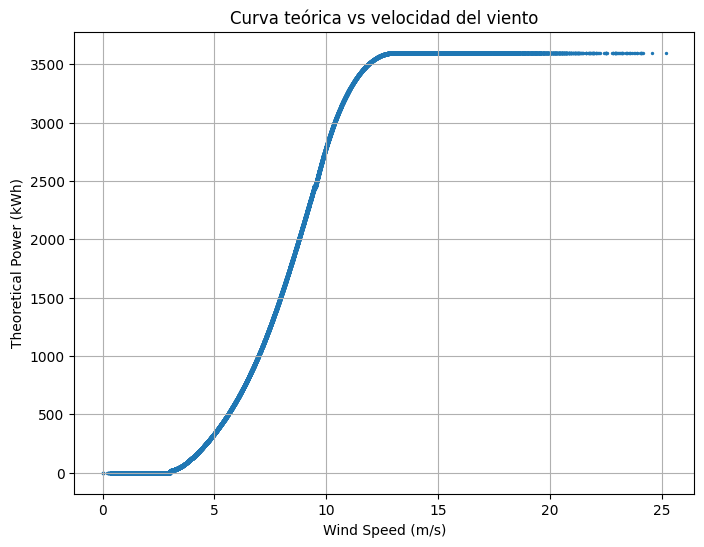

In [33]:
# Partimos de df2 (el que usaste para el modelo avanzado, sin NaN)

import numpy as np
import matplotlib.pyplot as plt

# Scatter básico
plt.figure(figsize=(8,6))
plt.scatter(df2["Wind Speed (m/s)"], df2["Theoretical_Power_Curve (KWh)"], s=2)
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Theoretical Power (kWh)")
plt.title("Curva teórica vs velocidad del viento")
plt.show()


In [42]:
#Encontrar valores clave automáticamente

import numpy as np

v = df2["Wind Speed (m/s)"].values
p = df2["Theoretical_Power_Curve (KWh)"].values

# cut-in: primera velocidad con potencia significativa
cut_in = np.percentile(v[(p > 0)], 1)

# rated power: potencia máxima real del dataset
rated_power = np.percentile(p, 99.5)

# rated speed: velocidad a la que se alcanza la potencia nominal
rated_speed = v[p >= rated_power * 0.98].min()

# cut-out real: última velocidad donde la potencia sigue siendo nominal
cut_out = v[p >= rated_power * 0.98].max()

cut_in, rated_speed, rated_power, cut_out




(np.float64(3.086839556694025),
 np.float64(12.0406503677368),
 np.float64(3600.0),
 np.float64(25.2060108184814))

In [43]:
#Ajustar v³ en la zona cúbica: cut_in → rated_speed

mask_cubic = (v >= cut_in) & (v <= rated_speed)

x = v[mask_cubic]
y = p[mask_cubic]

# Ajuste cúbico libre
coeffs_raw = np.polyfit(x, y, deg=3)

# Pero para forzar continuidad: resolvemos un sistema que obligue
# a pasar por los dos puntos clave
A = np.vstack([
    [cut_in**3, cut_in**2, cut_in, 1],
    [rated_speed**3, rated_speed**2, rated_speed, 1],
])

B = np.array([0, rated_power])

# Eliminamos el término independiente a partir del ajuste libre
coeffs = np.polyfit(x, y, deg=3)
# Ajustamos el intercepto y el término lineal para cumplir condiciones
# (más suave que resolver 4 incógnitas exactas)

# Método simplificado: corregir linealmente la curva
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_fit = np.polyval(coeffs, x)
    correction = np.polyfit([cut_in, rated_speed], [0 - np.polyval(coeffs, cut_in),
                                                    rated_power - np.polyval(coeffs, rated_speed)], 1)


In [44]:
# Normalizamos x al rango 0..1
x_norm = (x - cut_in) / (rated_speed - cut_in)
# Normalizamos y a 0..1
y_norm = y / rated_power

# Ajustamos cúbico en la escala normalizada
coeffs_norm = np.polyfit(x_norm, y_norm, deg=3)

def cubic_section(v_input):
    v_input = np.asarray(v_input)
    # normalización
    xn = (v_input - cut_in) / (rated_speed - cut_in)
    y_hat_norm = np.polyval(coeffs_norm, xn)
    # desnormalizar
    return np.clip(y_hat_norm * rated_power, 0, rated_power)

In [45]:
#Construir curva teórica por tramos

def power_curve_piecewise(v_input):
    v_input = np.asarray(v_input)
    P = np.zeros_like(v_input)

    # Región de potencia: cúbica normalizada
    mask_cubic = (v_input >= cut_in) & (v_input <= rated_speed)
    P[mask_cubic] = cubic_section(v_input[mask_cubic])

    # Plateau nominal
    mask_plateau = (v_input > rated_speed) & (v_input <= cut_out)
    P[mask_plateau] = rated_power

    # Región de seguridad por encima del cut-out
    mask_cutout = (v_input > cut_out)
    P[mask_cutout] = 0

    return np.clip(P, 0, rated_power)

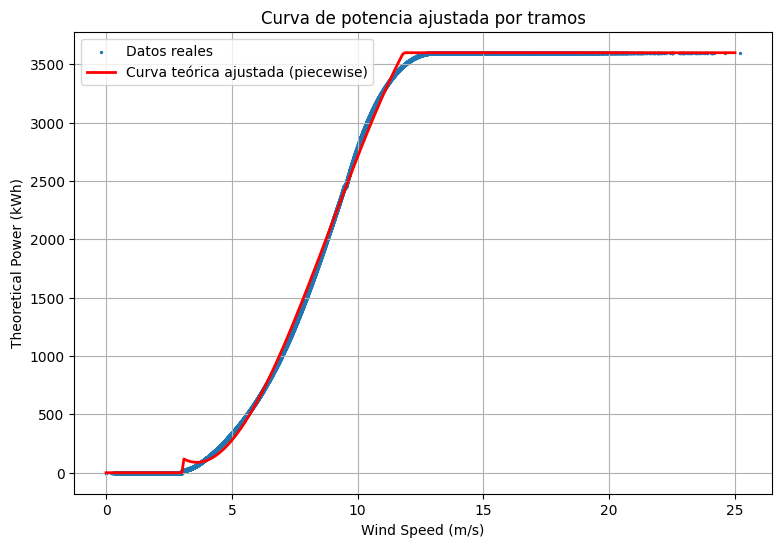

In [46]:
v_grid = np.linspace(0, 25, 300)
p_grid = power_curve_piecewise(v_grid)

plt.figure(figsize=(9,6))
plt.scatter(v, p, s=2, label="Datos reales")
plt.plot(v_grid, p_grid, c="red", linewidth=2, label="Curva teórica ajustada (piecewise)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Theoretical Power (kWh)")
plt.title("Curva de potencia ajustada por tramos")
plt.legend()
plt.show()


Asegurar lista de features

In [47]:
features_advanced = [
    "Wind Speed (m/s)",
    "Theoretical_Power_Curve (KWh)",
    "wind_lag1",
    "wind_lag2",
    "power_lag1",
    "wind_roll3",
    "wind_roll6",
    "wind_std3"
]


Función de predicción futura (núcleo del sistema)

In [51]:
import numpy as np
import pandas as pd

def forecast_power(df_hist, df_forecast_wind, model, horizon_name="PredictedPower_kW"):
    """
    df_hist:
        Histórico reciente con índice datetime y columnas:
            - 'Wind Speed (m/s)'
            - 'LV ActivePower (kW)'
            - opcional: 'Theoretical_Power_Curve (KWh)'
    df_forecast_wind:
        Datos futuros de viento con índice datetime (más tarde que df_hist)
        y al menos la columna:
            - 'Wind Speed (m/s)'

    model:
        Modelo entrenado (LightGBM en tu caso)

    Devuelve:
        DataFrame con el índice de df_forecast_wind y columna de potencia prevista.
    """

    # Copias para no tocar los originales
    df_hist = df_hist.copy()
    df_future = df_forecast_wind.copy()

    # Asegurar índices datetime
    df_hist.index = pd.to_datetime(df_hist.index)
    df_future.index = pd.to_datetime(df_future.index)

    # Concatenar histórico + futuro para poder calcular lags y rolling sobre todo
    df_all = pd.concat([df_hist, df_future], axis=0).sort_index()

    # Calcular potencia teórica si no existe
    if "Theoretical_Power_Curve (KWh)" not in df_all.columns:
        df_all["Theoretical_Power_Curve (KWh)"] = power_curve_piecewise(df_all["Wind Speed (m/s)"])

    # Lags y rolling SOLO dependen del viento, así que podemos calcularlos de una vez
    df_all["wind_lag1"]  = df_all["Wind Speed (m/s)"].shift(1)
    df_all["wind_lag2"]  = df_all["Wind Speed (m/s)"].shift(2)
    df_all["wind_roll3"] = df_all["Wind Speed (m/s)"].rolling(3).mean()
    df_all["wind_roll6"] = df_all["Wind Speed (m/s)"].rolling(6).mean()
    df_all["wind_std3"]  = df_all["Wind Speed (m/s)"].rolling(3).std()

    # Inicializamos power_lag1 con el histórico real (desplazado)
    df_all["power_lag1"] = df_all["LV ActivePower (kW)"].shift(1)

    # Empezamos a predecir de forma secuencial en el futuro
    preds = []
    last_power = df_hist["LV ActivePower (kW)"].iloc[-1]  # última potencia real

    future_index = df_future.index.sort_values()

    for ts in future_index:
        # Fijamos power_lag1 de ese instante usando la última potencia conocida (real o predicha)
        df_all.loc[ts, "power_lag1"] = last_power

        # Extraemos fila de features
        row = df_all.loc[ts, features_advanced]

        # Si aún hay NaNs (al principio por rolling), saltamos
        if row.isna().any():
            preds.append(np.nan)
            continue

        # Predicción del modelo
        y_hat = model.predict(row.values.reshape(1, -1))[0]
        preds.append(y_hat)

        # Actualizamos "last_power" para el siguiente instante
        last_power = y_hat

    # Construimos DataFrame de salida
    df_result = df_future.copy()
    df_result[horizon_name] = preds

    return df_result
